Figure 1: Discovery of correlated neighboring gene clusters. A The number of clusters in each tissue vs the percent of all expressed genes in the tissue that are in a cluster. B Example heatmap of a cluster of six HOXB genes with correlated expression in esophagus muscularis, colored by Spearman correlation coefficient. C Distribution of the number of genes per cluster. D Number of clusters with genes that are only positively correlated to one another, only negatively correlated, or have a mix of positive and negative correlation. E Enrichment of correlated clusters vs uncorrelated null clusters (methods), split for clusters with all positive correlation, all negative correlation, or a mix of positive and negative correlation. Categories where the expected frequency wat less than 5 were skipped. Error bars are 95% CIs on odds ratios for logistic regression (X: skipped, ns: p > 0.05, *: 0.05 > p > 10-2, **: 10-2 > p > 10-3, ***: p < 10-3).

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm 
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch

tqdm.pandas()

# get outputs from a config file
prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from annotate_clusters import * 


%config InlineBackend.figure_formats = ['png']

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

In [14]:
# colors
corr_cmap = LinearSegmentedColormap.from_list('corr', [(0, '#69AED1'), (.5, 'white'), (1, '#B83A4B')])

gtex_tissue_dict = {
    "Adipose_Subcutaneous": "#FFA54F",
    "Adipose_Visceral_Omentum": "#EE9A00",
    "Artery_Tibial": "#FF0000",
    "Cells_Cultured_fibroblasts": "#9AC0CD",
    "Esophagus_Mucosa": "#8B7355",
    "Esophagus_Muscularis": "#CDAA7D",
    "Lung": "#9ACD32",
    "Muscle_Skeletal": "#7A67EE",
    "Nerve_Tibial": "#FFD700",
    "Skin_Not_Sun_Exposed_Suprapubic": "#3A5FCD",
    "Skin_Sun_Exposed_Lower_leg": "#1E90FF",
    "Thyroid": "#008B45",
    "Whole_Blood": "#FF00FF"
}

gtex_tissue_pal = sns.color_palette(list(gtex_tissue_dict.values()))
gtex_tissue_pal_df = pd.DataFrame(pd.Series(gtex_tissue_dict), columns=['hex']).reset_index(names=['tissue_id'])


In [15]:
# load in clusters
clusters = load_across_tissues(config, load_clusters_annotated)

# get total number of clusters and genes in clusters
cluster_counts = clusters.groupby('tissue_id').agg({'num_genes':'sum', 'cluster_id':'nunique'}).reset_index()
tissue_ids = load_tissue_ids(config)

# get total number of expressed genes
num_expressed_genes = [len(load_expression(config, tissue_id)) for tissue_id in tissue_ids]
cluster_counts['expressed_genes'] = num_expressed_genes
cluster_counts['fraction_genes_in_cluster'] = cluster_counts['num_genes']/cluster_counts['expressed_genes']*100

In [16]:
# Example cluster correaltion 
gencode = pd.read_table(f"{config['working_dir']}/{config['gencode_path']}")
gid_gencode = gencode.set_index('gene_id')

example_cluster = clusters[clusters['cluster_id']=='ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4'].iloc[0]

# gene gene ids sorted by tss start
sorted_cluster = gid_gencode.loc[example_cluster['cluster_id'].split('_')].sort_values('start')
sorted_gene_ids = sorted_cluster.index.values
# get normed expression 
expression = load_cluster_expression(config, example_cluster['tissue_id'])
expression['cluster_id'] = expression['gene_id'].str.split('_e_').str[0]
expression['egene_id'] = expression['gene_id'].str.split('_e_').str[1]
cluster_expression = expression[(expression['cluster_id']==example_cluster['cluster_id'])].set_index('egene_id').loc[sorted_gene_ids]
# get correlation of expression
sample_ids = cluster_expression.columns[cluster_expression.columns.str.contains('GTEX')]
cluster_corr, cluster_pvalue = spearmanr(cluster_expression[sample_ids], axis=1)
# make df with readable gene names
cluster_corr = pd.DataFrame(cluster_corr, index=sorted_cluster['gene_name'].values, columns=sorted_cluster['gene_name'].values)

In [17]:
clusters[['mean_pos_corr', 'mean_neg_corr']] = clusters[['mean_pos_corr', 'mean_neg_corr']].fillna(0)
clusters['positive correlation'] = clusters['mean_pos_corr'] != 0
clusters['negative correlation'] = clusters['mean_neg_corr'] != 0
clusters_upset = clusters.set_index('positive correlation').set_index('negative correlation', append=True)

In [18]:
# load clusters
annotated_clusters = load_across_tissues(config,load_clusters_annotated)
annotated_clusters['cluster_length'] = np.log10(annotated_clusters['end'].astype(int) - annotated_clusters['start'].astype(int))
annotated_clusters['mean_pos_corr'] = np.where(annotated_clusters['mean_pos_corr']==0, np.nan, annotated_clusters['mean_pos_corr'])
annotated_clusters['mean_neg_corr'] = np.where(annotated_clusters['mean_neg_corr']==0, np.nan, annotated_clusters['mean_neg_corr'])
annotated_clusters = annotated_clusters[annotated_clusters['num_genes']<6]


# load nulls
annotated_nulls = []
for tissue_id in load_tissue_ids(config):
    for num_genes in [2,3,4,5]:
        annotated_null_subset = load_null_clusters_annotated(config, tissue_id, num_genes)
        annotated_null_subset['cluster_length'] = np.log10(annotated_null_subset['end'].astype(int) - annotated_null_subset['start'].astype(int))
        annotated_null_subset['tissue_id'] = tissue_id
        annotated_nulls.append(annotated_null_subset)

annotated_null_clusters = pd.concat(annotated_nulls)

# modify overlapping to exclude promoters
def exclude_shared_promoters(cluster_df):
    has_shared_promoter = cluster_df['has_shared_same_promoter'] | cluster_df['has_shared_opp_promoter']
    cluster_df['has_opp_overlapping'] = cluster_df['has_opp_overlapping'] & ~has_shared_promoter
    cluster_df['has_same_overlapping'] = cluster_df['has_same_overlapping'] & ~has_shared_promoter
    return cluster_df

annotated_null_clusters = exclude_shared_promoters(annotated_null_clusters)
annotated_clusters = exclude_shared_promoters(annotated_clusters)


# Define annotation columns 
annotation_cols = ['has_paralog', 'has_go', 'has_same_overlapping', 'has_shared_same_promoter', 
    'has_abc', 'has_shared_opp_promoter', 'has_opp_overlapping', 'has_ctcf', 'has_tad']

# Set minimum thresholds for enrichment calculation
min_group_size = 10
min_expected_freq = 5

# Categorize clusters by correlation type
clusters_cat = categorize_correlation_type(annotated_clusters)

all_results = []

# Overall enrichment (all clusters vs null)
overall_enrichment = calculate_enrichment_with_covariates(
    annotated_clusters, annotated_null_clusters, annotation_cols, 
    min_group_size=min_group_size, min_expected_freq=min_expected_freq
)

# Add overall results
for _, row in overall_enrichment.iterrows():
    all_results.append({
        'annotation': row['annotation'],
        'corr_type': 'overall',
        'odds_ratio': row['odds_ratio'],
        'ci_lower': row['ci_lower'],
        'ci_upper': row['ci_upper'],
        'p_value': row['p_value'],
        'n_clusters': len(annotated_clusters),
        'n_null': len(annotated_null_clusters),
        'reason': row['reason']
    })

# Calculate enrichment for each correlation type vs null
corr_types = ['positive_only', 'negative_only', 'both_corr']

for corr_type in corr_types:
    clusters_subset = clusters_cat[clusters_cat['corr_type'] == corr_type]
    
    if len(clusters_subset) > 0:
        enrichment = calculate_enrichment_with_covariates(
            clusters_subset, annotated_null_clusters, annotation_cols,
            min_group_size=min_group_size, min_expected_freq=min_expected_freq
        )
        
        for _, row in enrichment.iterrows():
            all_results.append({
                'annotation': row['annotation'],
                'corr_type': corr_type,
                'odds_ratio': row['odds_ratio'],
                'ci_lower': row['ci_lower'],
                'ci_upper': row['ci_upper'],
                'p_value': row['p_value'],
                'n_clusters': len(clusters_subset),
                'n_null': len(annotated_null_clusters),
                'reason': row['reason']
            })
    else:
        # Add NA entries for this correlation type
        for annotation in annotation_cols:
            all_results.append({
                'annotation': annotation,
                'corr_type': corr_type,
                'odds_ratio': np.nan,
                'ci_lower': np.nan,
                'ci_upper': np.nan,
                'p_value': np.nan,
                'n_clusters': 0,
                'n_null': len(annotated_null_clusters),
                'reason': 'no_clusters_of_this_type'
            })

results_df = pd.DataFrame(all_results)

Low expected frequency for has_shared_same_promoter: min_expected=4.46
Low expected frequency for has_same_overlapping: min_expected=0.87
Low expected frequency for has_shared_same_promoter: min_expected=0.60
Low expected frequency for has_opp_overlapping: min_expected=4.36


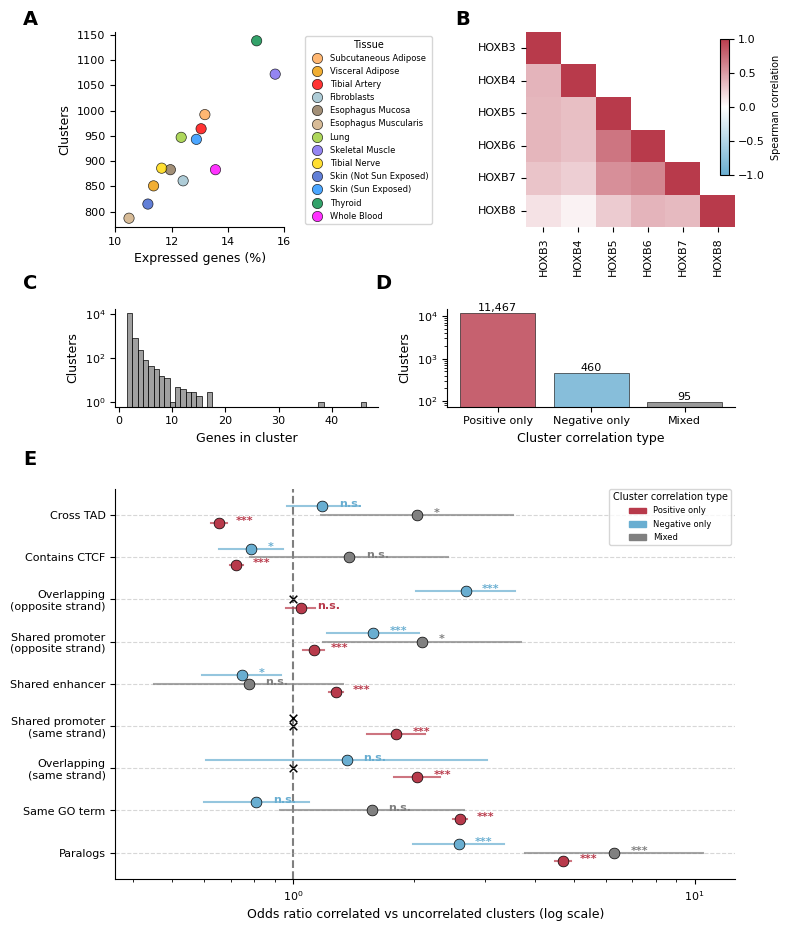

In [19]:
fig = plt.figure(figsize=(8, 11))
gs = GridSpec(
    3, 6, figure=fig,
    width_ratios=[1, 1, .5, .2, 1.8, 1],
    height_ratios=[1, .5, 2],
    hspace=0.36, wspace=1.5
)

# --- Panel A ---
ax_a = fig.add_subplot(gs[0, 0:2])
scatter = sns.scatterplot(
    cluster_counts, x='fraction_genes_in_cluster', y='cluster_id',
    hue='tissue_id', palette=gtex_tissue_pal, ax=ax_a, s=55, alpha=.8, legend=True, edgecolor='black', linewidth=0.5
)
ax_a.set_ylabel('Clusters')
ax_a.set_xlabel('Expressed genes (%)')
ax_a.set_xticks([10, 12, 14, 16])
ax_a.spines[['top', 'right']].set_visible(False)

legend = ax_a.get_legend()
if legend is not None:
    legend.remove()

ax_a_legend = fig.add_subplot(gs[0, 2:4])
ax_a_legend.axis('off')
legend_handles, legend_labels = ax_a.get_legend_handles_labels()
if legend_labels and legend_labels[0].lower() == 'tissue_id':
    legend_handles = legend_handles[1:]
    legend_labels = legend_labels[1:]
legend_labels = [lbl.replace("Skin_Not_Sun_Exposed_Suprapubic", "Skin (Not Sun Exposed)")
                    .replace("Skin_Sun_Exposed_Lower_leg", "Skin (Sun Exposed)")
                    .replace("Cells_Cultured_fibroblasts", "Fibroblasts")
                    .replace("Adipose_Subcutaneous", "Subcutaneous Adipose")
                    .replace("Adipose_Visceral_Omentum", "Visceral Adipose")
                    .replace("Muscle_Skeletal", "Skeletal Muscle")
                    .replace("Nerve_Tibial", "Tibial Nerve")
                    .replace("Artery_Tibial", "Tibial Artery")
                for lbl in legend_labels]
legend_labels = [lbl.replace('_', ' ') for lbl in legend_labels]

ax_a_legend.legend(
    legend_handles, legend_labels,
    title="Tissue", frameon=True, fontsize=6, loc="upper left",
    title_fontsize=7, labelspacing=0.5, handletextpad=0.5, bbox_to_anchor=(-.5, 1)
)

# --- Panel B ---
ax_b = fig.add_subplot(gs[0, 4:])
import matplotlib as mpl
mask = np.triu(np.ones_like(cluster_corr), k=1)
heatmap = sns.heatmap(
    cluster_corr, mask=mask,
    cmap=corr_cmap, vmin=-1, vmax=1, ax=ax_b,
    cbar=False,
    xticklabels=True, yticklabels=True)
ax_b.tick_params(axis="y", rotation=0)
ax_b.tick_params(axis="x", rotation=90)
ax_b.spines[['top', 'right']].set_visible(False)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = inset_axes(ax_b, width="4%", height="70%", loc='upper right', borderpad=0.6)
cbar = fig.colorbar(
    heatmap.collections[0],
    cax=cax,
    orientation='vertical'
)
cbar.set_label("Spearman correlation", fontsize=7)
cbar.ax.tick_params(labelsize=8)

# --- Panel C ---
ax_c = fig.add_subplot(gs[1, 0:3])
sns.histplot(clusters, x='num_genes', ax=ax_c, color='grey', discrete=True, edgecolor='black', linewidth=0.5)
ax_c.spines[['top', 'right']].set_visible(False)
ax_c.set_yscale('log')
ax_c.set_ylabel('Clusters')
ax_c.set_xlabel('Genes in cluster')
ax_c.set_yticks([1, 100, 10000])

# --- Panel D ---
ax_d = fig.add_subplot(gs[1, 3:6])
clusters['corr_type'] = np.where(
    (clusters['positive correlation']) & (~clusters['negative correlation']), 'positive_only',
    np.where((~clusters['positive correlation']) & (clusters['negative correlation']), 'negative_only', 'mixed')
)
corr_counts = clusters['corr_type'].value_counts()
bar_colors = ['#B83A4B', '#69AED1', 'grey']
bars = ax_d.bar(range(len(corr_counts)), corr_counts.values, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax_d.set_ylabel('Clusters')
ax_d.set_xticks(range(len(corr_counts)))
ax_d.set_xticklabels(['Positive only', 'Negative only', 'Mixed'])
ax_d.set_xlabel('Cluster correlation type')
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)
ax_d.set_yscale('log')
for bar, count in zip(bars, corr_counts.values):
    height = bar.get_height()
    ax_d.text(
        bar.get_x() + bar.get_width()/2., height + height*0.01,
        f'{count:,}', ha='center', va='bottom', fontsize=8)

# --- Panel E --
ax_e = fig.add_subplot(gs[2, :])

enrich_colors = {
    'positive_only': '#B83A4B',
    'both_corr': 'grey',
    'negative_only': '#69AED1'
}
plot_data = results_df[(results_df['corr_type'] != 'overall') & (results_df['reason'] == 'success')]
skipped_data = results_df[(results_df['corr_type'] != 'overall') & (results_df['reason'] != 'success')]
y_positions = {annotation: i for i, annotation in enumerate(annotation_cols)}

for corr_type in ['positive_only', 'both_corr', 'negative_only']:
    subset = plot_data[plot_data['corr_type'] == corr_type]
    if len(subset) == 0:
        continue
    offset = (list(enrich_colors.keys()).index(corr_type) - 1) * 0.2
    y_vals = [y_positions[ann] + offset for ann in subset['annotation']]
    ax_e.scatter(
        subset['odds_ratio'], y_vals,
        color=enrich_colors[corr_type], s=60, zorder=3, edgecolors='black', linewidth=0.5, label=corr_type if offset==0 else None)
    for idx, (_, row) in enumerate(subset.iterrows()):
        y_val = y_vals[idx]
        ax_e.plot([row['ci_lower'], row['ci_upper']], [y_val, y_val],
                  color=enrich_colors[corr_type], alpha=0.7, linewidth=1.5, zorder=2)
        if pd.notna(row['p_value']):
            if row['p_value'] < 0.001:
                marker = '***'
            elif row['p_value'] < 0.01:
                marker = '**'
            elif row['p_value'] < 0.05:
                marker = '*'
            else:
                marker = 'n.s.'
            if marker:
                ax_e.text(row['odds_ratio'] * 1.1, y_val + .05, marker,
                          va='center', color=enrich_colors[corr_type], fontweight='bold', zorder=4)

for corr_type in ['positive_only', 'both_corr', 'negative_only']:
    subset_skipped = skipped_data[skipped_data['corr_type'] == corr_type]
    if len(subset_skipped) == 0:
        continue
    offset = (list(enrich_colors.keys()).index(corr_type) - 1) * 0.2
    y_vals_skipped = [y_positions[ann] + offset for ann in subset_skipped['annotation']]
    ax_e.scatter([1] * len(y_vals_skipped), y_vals_skipped,
                 marker='x', color='k', s=30, zorder=1, linewidth=1.1)

legend_handles = [
    Patch(color=enrich_colors['positive_only'], label='Positive only'),
    Patch(color=enrich_colors['negative_only'], label='Negative only'),
    Patch(color=enrich_colors['both_corr'], label='Mixed')
]
ax_e.legend(handles=legend_handles, title="Cluster correlation type",
            frameon=True, loc='upper right', bbox_to_anchor=(1, 1.01), 
            fontsize=6, title_fontsize=7)

ax_e.axvline(x=1, color='black', linestyle='--', alpha=0.5, zorder=1)
ax_e.set_xlabel('Odds ratio correlated vs uncorrelated clusters (log scale)')
ax_e.set_yticks(range(len(annotation_cols)))
ax_e.set_yticklabels([
    'Paralogs', 'Same GO term', 'Overlapping\n(same strand)', 'Shared promoter\n(same strand)', 
    'Shared enhancer', 'Shared promoter\n(opposite strand)', 'Overlapping\n(opposite strand)', 
    'Contains CTCF', 'Cross TAD'
])
ax_e.set_xscale('log')
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)
if len(plot_data) > 0:
    min_or = plot_data['ci_lower'].min()
    max_or = plot_data['ci_upper'].max()
    x_margin = 0.2
    ax_e.set_xlim(min_or * (1 - x_margin), max_or * (1 + x_margin))
ax_e.grid(axis='y', linestyle='--', alpha=0.5)

x_left = 0.01
x_middle = 0.45
x_right = 0.55

y_top = 0.9
y_middle = 0.66
y_bottom = 0.5

fig.text(x_left,  y_top,    'A', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_right, y_top,    'B', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_left,  y_middle, 'C', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_middle, y_middle, 'D', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(x_left,  y_bottom, 'E', fontsize=14, fontweight='bold', ha='left', va='top')

plt.savefig(f"{config['working_dir']}/workflow/main_figures/figures/figure_1_combined.pdf",
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()